# Datathon 7MLET
- Camilly Alves

# Etapa 1 — Base Kaggle e Análise Exploratória (EDA)

**Problema de negócio:** uma instituição financeira digital precisa decidir, em diferentes canais, qual oferta apresentar para cada cliente elegível. Neste notebook usamos a base **Bank Marketing** como proxy factual para o problema de conversão/propensão, que servirá de base para a estratégia de bandit adaptativo nas próximas etapas.

**Base Kaggle escolhida:** [Bank Marketing Dataset — henriqueyamahata](https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing)

- Fonte original: UCI Machine Learning Repository (Moro, Cortez & Rita, 2014)
- Licença: uso livre para fins educacionais/pesquisa (CC-like, conforme UCI)
- Arquivo utilizado: `bank-full.csv` (45.211 linhas, 17 colunas)
- **Target (proxy de conversão):** coluna `y` — cliente aderiu ao depósito a prazo (`yes`/`no`)

> Observação: como o ambiente de execução deste notebook não possui acesso direto ao Kaggle, o CSV foi obtido de um mirror público com conteúdo idêntico ao dataset original. **Para reproduzir localmente, baixe o arquivo diretamente do Kaggle** usando o link acima e substitua o caminho na célula de carregamento abaixo.


In [1]:
# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)


## 1. Carregamento da base

O arquivo original do Kaggle/UCI usa `;` como separador e strings entre aspas. Ajustamos a leitura para isso.

# Dados do cliente bancário:
- 1 - age (numérico)
- 2 - job : tipo de trabalho (categórico: "admin.","blue-collar","entrepreneur","housemaid","management","retired","self-employed","services","student","technician","unemployed","unknown")
- 3 - marital : estado civil (categórico: "divorced","married","single","unknown"; nota: "divorced" significa divorciado ou viúvo)
- 4 - education (categórico: "basic.4y","basic.6y","basic.9y","high.school","illiterate","professional.course","university.degree","unknown")
- 5 - default: possui crédito em situação de inadimplência? (categórico: "não", "sim", "desconhecido")
- 6 - housing: possui empréstimo habitacional? (categórico: "não", "sim", "desconhecido")
- 7 - loan: possui empréstimo pessoal? (categórico: "não", "sim", "desconhecido")
## relacionado ao último contato da campanha atual:
- 8 - contact: tipo de comunicação do contato (categórico: "celular", "telefone")
- 9 - month: mês do ano do último contato (categórico: "jan", "fev", "mar", ..., "nov", "dez")
- 10 - day_of_week: dia da semana do último contato (categórico: "seg", "ter", "qua", "qui", "sex")
- 11 - duration: duração do último contato, em segundos (numérico). Nota importante: este atributo afeta fortemente o alvo de saída (por exemplo, se duration=0, então y="não"). No entanto, a duração não é conhecida antes de uma chamada ser realizada. Além disso, após o término da chamada, y é obviamente conhecido. Assim, esta entrada deve ser incluída apenas para fins de referência (benchmark) e deve ser descartada se a intenção for obter um modelo preditivo realista.
## outros atributos:
- 12 - campaign: número de contatos realizados durante esta campanha e para este cliente (numérico, inclui o último contato)
- 13 - pdays: número de dias decorridos desde que o cliente foi contatado pela última vez em uma campanha anterior (numérico; 999 significa que o cliente não foi contatado anteriormente)
- 14 - previous: número de contatos realizados antes desta campanha e para este cliente (numérico)
- 15 - poutcome: resultado da campanha de marketing anterior (categórico: "falha", "inexistente", "sucesso")
## atributos de contexto social e econômico
- 16 - emp.var.rate: taxa de variação do emprego - indicador trimestral (numérico)
- 17 - cons.price.idx: índice de preços ao consumidor - indicador mensal (numérico)
- 18 - cons.conf.idx: índice de confiança do consumidor - indicador mensal (numérico)
- 19 - euribor3m: taxa Euribor de 3 meses - indicador diário (numérico)
- 20 - nr.employed: número de empregados


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("henriqueyamahata/bank-marketing")

print("Path to dataset files:", path)

100%|██████████| 393k/393k [00:00<00:00, 79.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/henriqueyamahata/bank-marketing/versions/1


In [7]:
import os

path = "/root/.cache/kagglehub/datasets/henriqueyamahata/bank-marketing/versions/1"
print(os.listdir(path))

['bank-additional-names.txt', 'bank-additional-full.csv']


In [8]:
df = pd.read_csv(f"{path}/bank-additional-full.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [11]:
#Documentação das colunas
#with open(f"{path}/bank-additional-names.txt") as f:
#    print(f.read())

In [12]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

## 2. Dicionário rápido de colunas

| Coluna | Descrição |
|---|---|
| age | idade do cliente |
| job | tipo de emprego |
| marital | estado civil |
| education | nível de educação |
| default | possui crédito em default? |
| balance | saldo médio anual (euros) |
| housing | possui financiamento imobiliário? |
| loan | possui empréstimo pessoal? |
| contact | tipo de contato de comunicação |
| day / month | dia/mês do último contato |
| duration | duração do último contato em segundos (**vazamento — remover**) |
| campaign | nº de contatos realizados nesta campanha |
| pdays | dias desde o último contato de campanha anterior (-1 = nunca contatado) |
| previous | nº de contatos antes desta campanha |
| poutcome | resultado da campanha anterior |
| y | **target** — cliente aderiu ao depósito a prazo? |


## 3. Qualidade dos dados: nulos, duplicados e valores "unknown"

A base não tem `NaN` explícitos, mas usa a string `"unknown"` como categoria ausente em várias colunas categóricas.


In [13]:
# Nulos "de verdade"
print("Valores nulos (NaN) por coluna:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else "Nenhum NaN encontrado.")

# Duplicados
print(f"\nLinhas duplicadas: {df.duplicated().sum()}")

# "unknown" como missing disfarçado
print("\nProporção de 'unknown' por coluna categórica:")
cat_cols = df.select_dtypes(include='object').columns.tolist()
for c in cat_cols:
    pct = (df[c] == 'unknown').mean()
    if pct > 0:
        print(f"  {c}: {pct:.1%}")


Valores nulos (NaN) por coluna:
Nenhum NaN encontrado.

Linhas duplicadas: 12

Proporção de 'unknown' por coluna categórica:
  job: 0.8%
  marital: 0.2%
  education: 4.2%
  default: 20.9%
  housing: 2.4%
  loan: 2.4%


In [14]:
# Remover duplicados, se houver
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Linhas removidas por duplicidade: {n_before - len(df)}")


Linhas removidas por duplicidade: 12


## 4. Remoção de coluna com vazamento temporal (leakage)

A coluna **`duration`** representa a duração da última ligação em segundos. Esse valor só é conhecido **depois** que o contato acontece e está fortemente correlacionado com a conversão (chamadas mais longas quase sempre terminam em `yes`). Usá-la faria o modelo "trapacear", pois na hora de decidir qual oferta fazer **ainda não sabemos** quanto tempo a ligação vai durar.

Por isso, seguindo a orientação do desafio, **removemos `duration`** do conjunto de features.


In [15]:
df = df.drop(columns=['duration'])
print("Coluna 'duration' removida. Shape atual:", df.shape)


Coluna 'duration' removida. Shape atual: (41176, 20)


## 5. Distribuição do target (`y`)

Ponto central para o desafio de bandits: entender o desbalanceamento da taxa de conversão baseline.


y
no     36537
yes     4639
Name: count, dtype: int64
y
no     0.8873
yes    0.1127
Name: proportion, dtype: float64


/tmp/ipykernel_2366/2428509142.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='y', ax=ax, palette=['#4C72B0', '#DD8452'])


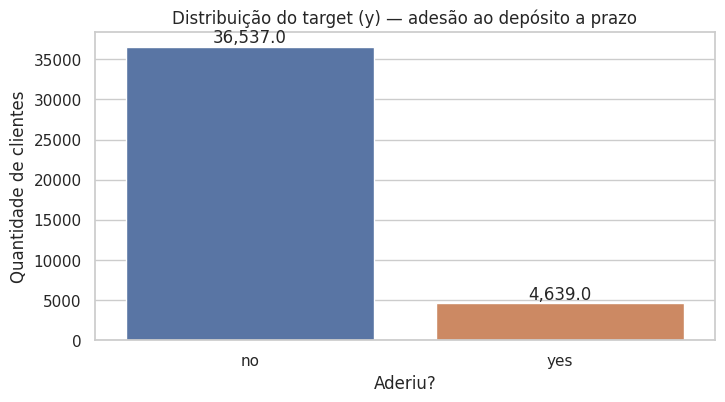

In [16]:
target_counts = df['y'].value_counts()
target_pct = df['y'].value_counts(normalize=True)

print(target_counts)
print(target_pct.round(4))

fig, ax = plt.subplots()
sns.countplot(data=df, x='y', ax=ax, palette=['#4C72B0', '#DD8452'])
ax.set_title('Distribuição do target (y) — adesão ao depósito a prazo')
ax.set_xlabel('Aderiu?')
ax.set_ylabel('Quantidade de clientes')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()


**Observação:** a base é bastante desbalanceada — cerca de 88% dos clientes não convertem (`no`) e ~12% convertem (`y`). Essa taxa geral (~11-12%) será usada mais adiante como referência para o **baseline determinístico** (Etapa 3).


## 6. Variáveis numéricas — distribuição e outliers


In [17]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Colunas numéricas:", num_cols)

df[num_cols].describe().T


Colunas numéricas: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


,count,mean,std,min,25%,50%,75%,max
age,41176.0,40.023800,10.420680,17.000,32.000,38.000,47.000,98.000
campaign,41176.0,2.567879,2.770318,1.000,1.000,2.000,3.000,56.000
pdays,41176.0,962.464810,186.937102,0.000,999.000,999.000,999.000,999.000
previous,41176.0,0.173013,0.494964,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41176.0,0.081922,1.570883,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41176.0,93.575720,0.578839,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41176.0,-40.502863,4.627860,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41176.0,3.621293,1.734437,0.634,1.344,4.857,4.961,5.045
nr.employed,41176.0,5167.034870,72.251364,4963.600,5099.100,5191.000,5228.100,5228.100


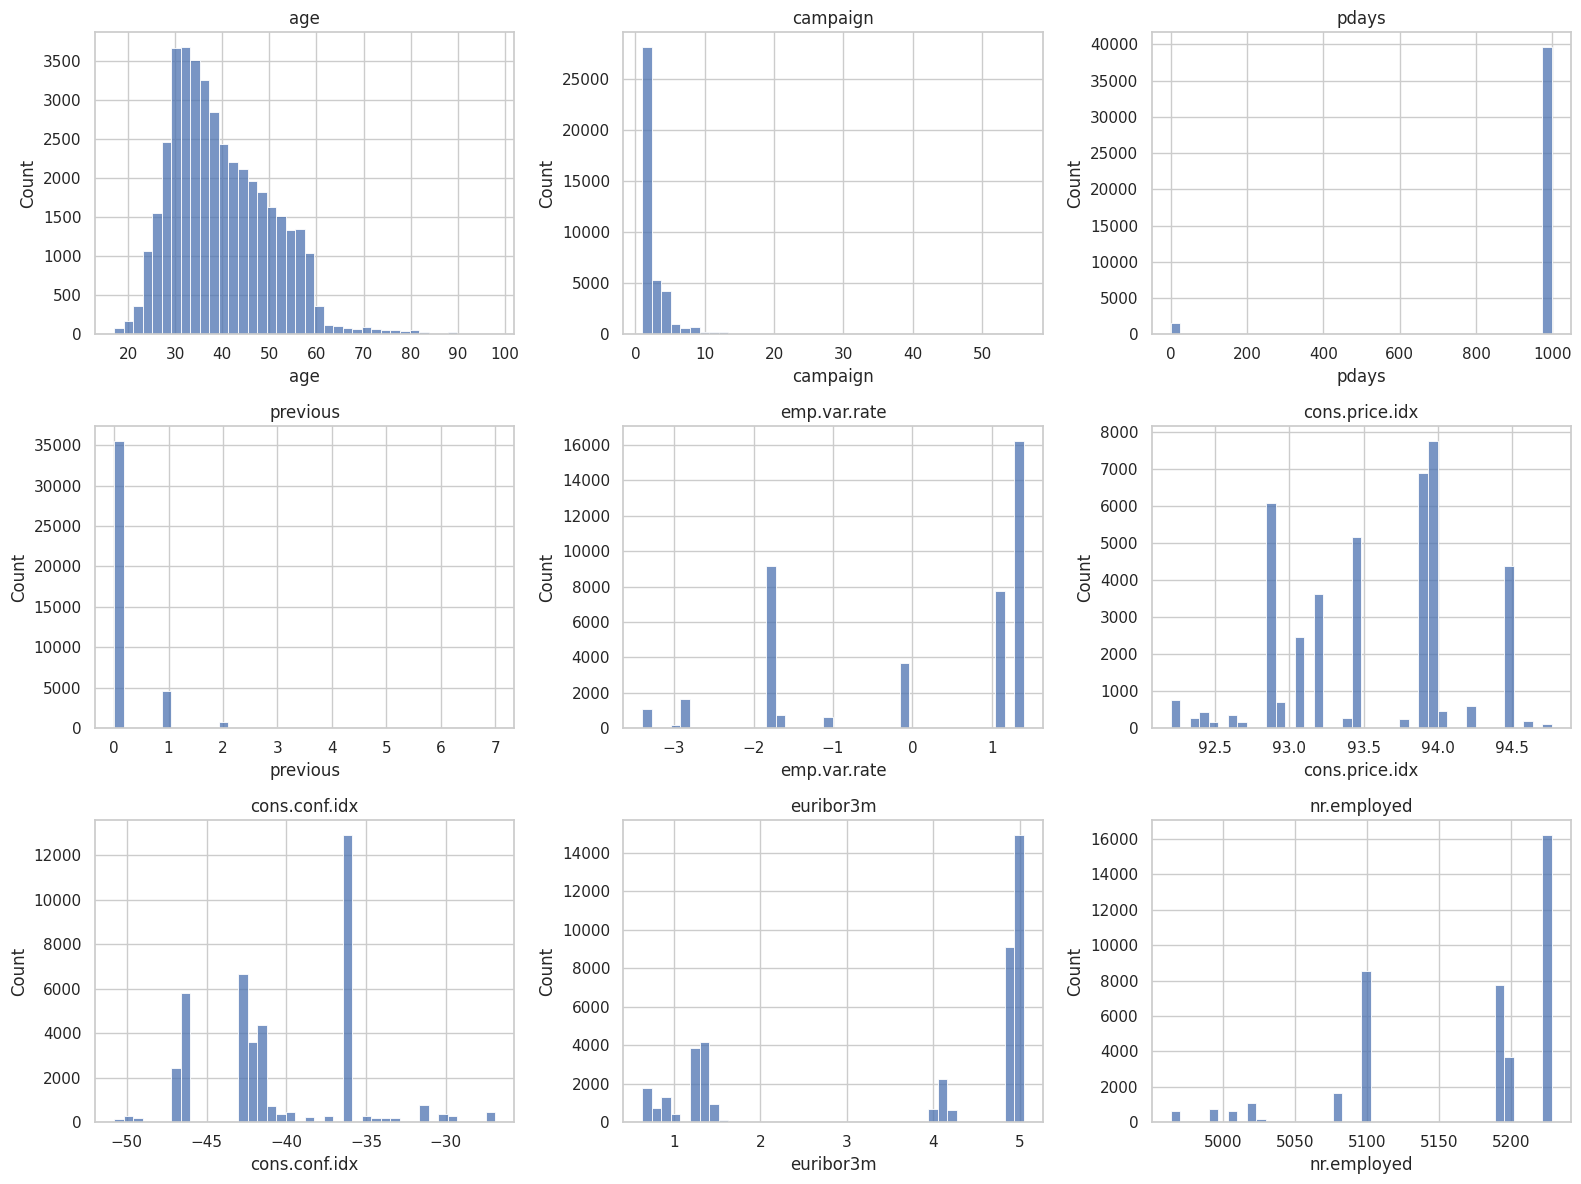

In [24]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=40, ax=axes[i], kde=False, color='#4C72B0')
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

IndexError: index 6 is out of bounds for axis 0 with size 6

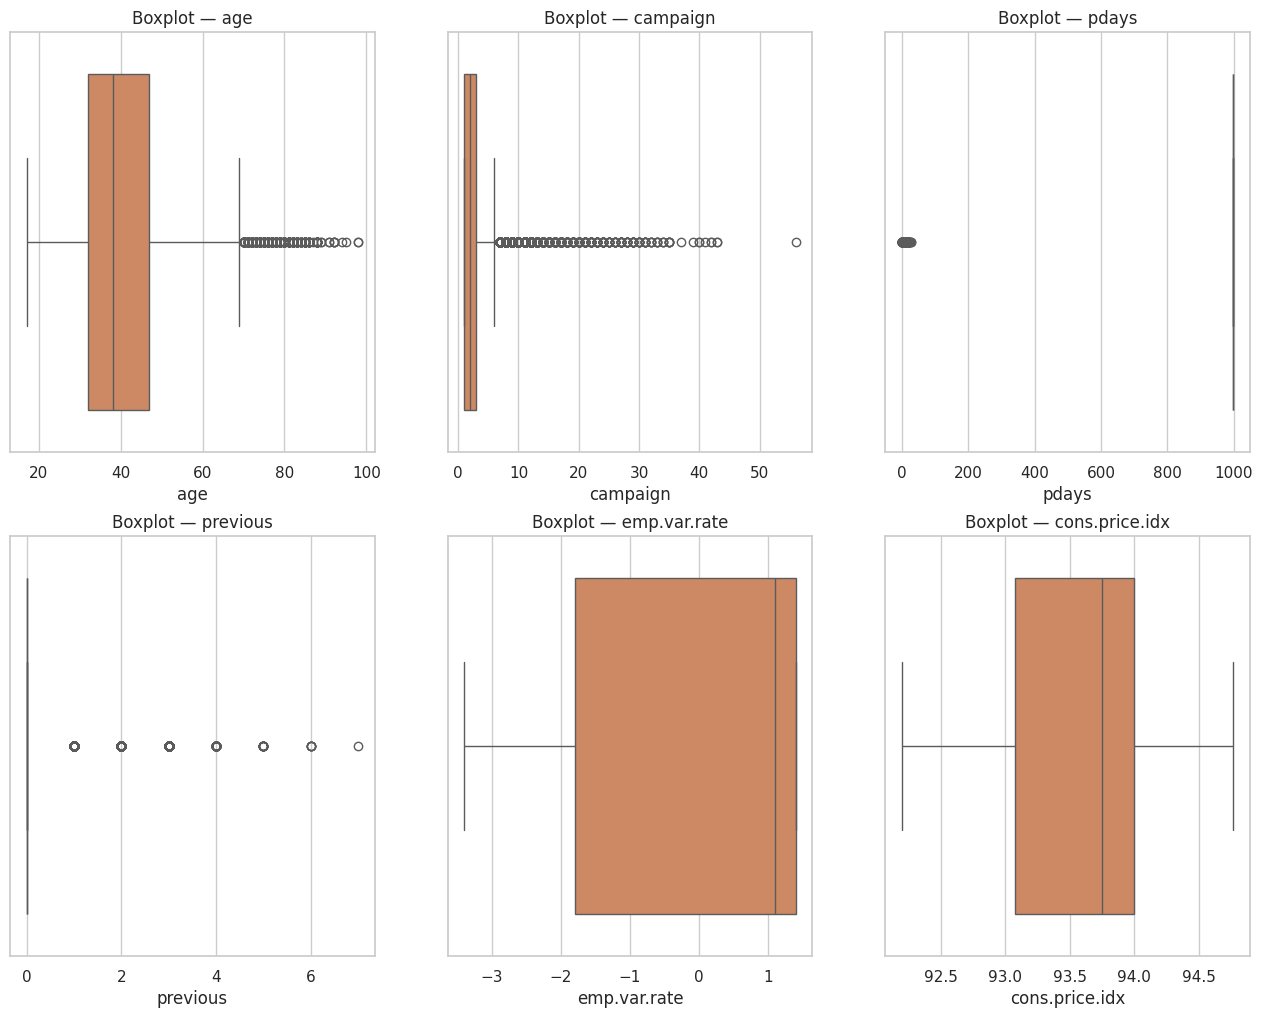

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='#DD8452')
    axes[i].set_title(f'Boxplot — {col}')
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


**Observações:**
- `balance` tem cauda longa à direita e valores negativos (clientes no vermelho) — esperado em saldo bancário, não é erro de dado.
- `pdays = -1` indica "nunca contatado antes" — não é outlier, é um código categórico disfarçado de número. Vale tratar como categoria própria na modelagem.
- `campaign` e `previous` também têm cauda longa (poucos clientes contatados muitas vezes).


## 7. Variáveis categóricas x taxa de conversão

Aqui já olhamos para o que vai virar "contexto" do bandit: quais segmentos de cliente convertem mais.


In [26]:
cat_cols_no_target = [c for c in cat_cols if c != 'y']
print("Colunas categóricas:", cat_cols_no_target)


Colunas categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


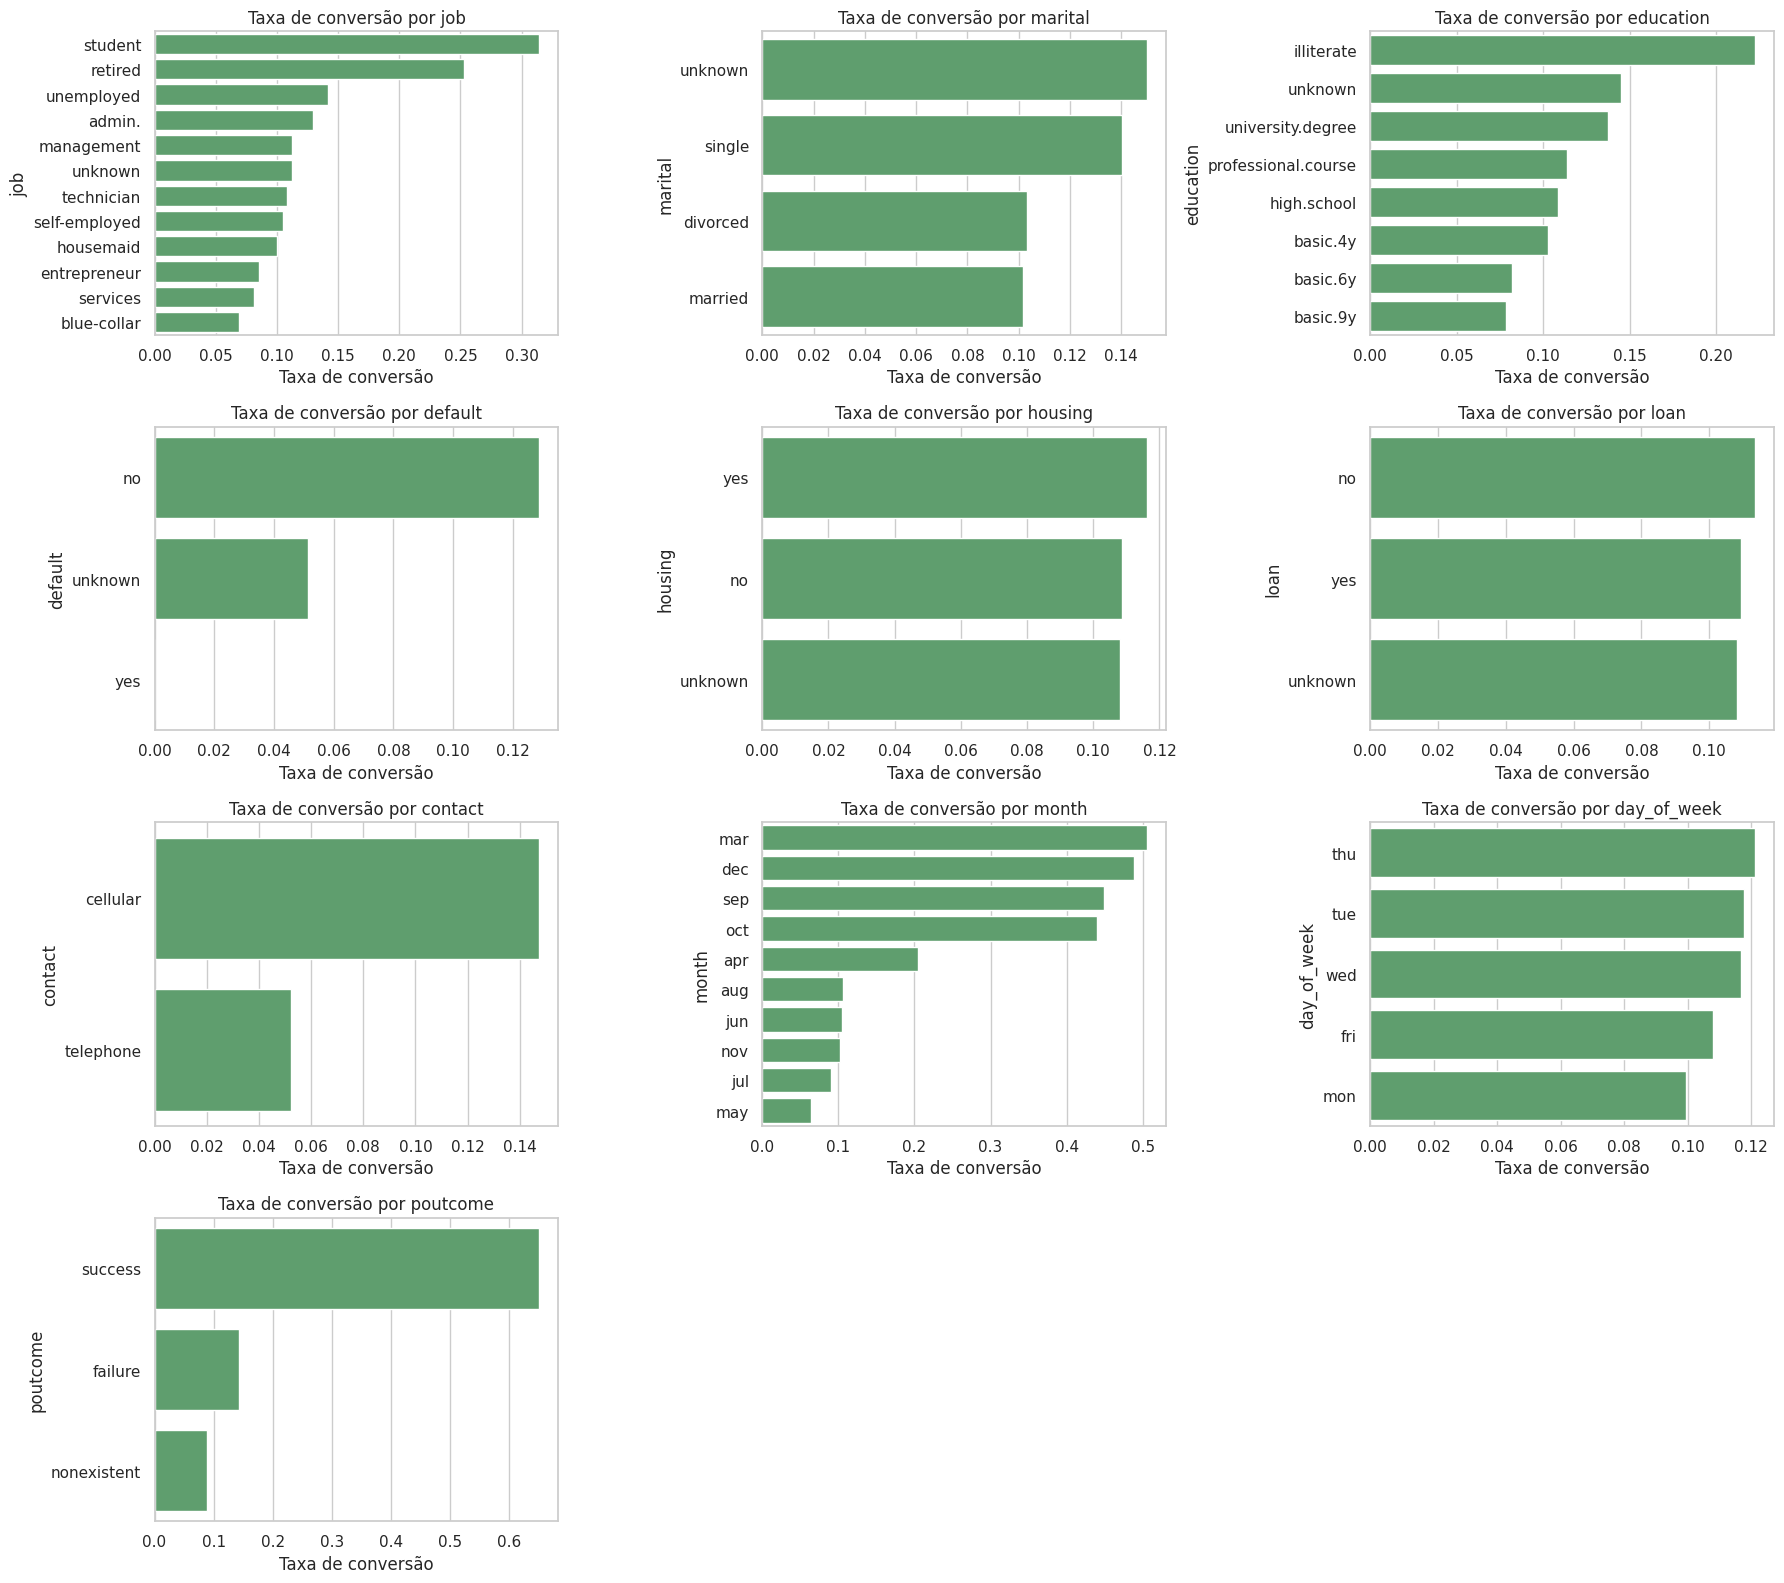

In [28]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16)) # Changed from 3,3 to 4,3 and increased figsize
axes = axes.flatten()
for i, col in enumerate(cat_cols_no_target):
    conv_rate = df.groupby(col)['y'].apply(lambda s: (s == 'yes').mean()).sort_values(ascending=False)
    sns.barplot(x=conv_rate.values, y=conv_rate.index, ax=axes[i], color='#55A868')
    axes[i].set_title(f'Taxa de conversão por {col}')
    axes[i].set_xlabel('Taxa de conversão')
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

**Leituras rápidas (a validar estatisticamente depois):**
- `poutcome = success` (cliente converteu em campanha anterior) tem taxa de conversão muito acima da média — forte sinal preditivo.
- `job` do tipo `student` e `retired` tendem a converter mais que `blue-collar` ou `entrepreneur`.
- Clientes sem `housing`/`loan` ativos convertem mais.
- `month` mostra sazonalidade (alguns meses convertem bem mais que outros).

Esses padrões reforçam por que uma abordagem **adaptativa** (bandit) faz sentido: diferentes segmentos reagem de forma muito distinta, então tratar todo mundo com a mesma regra fixa desperdiça oportunidade.


## 8. Correlação entre variáveis numéricas


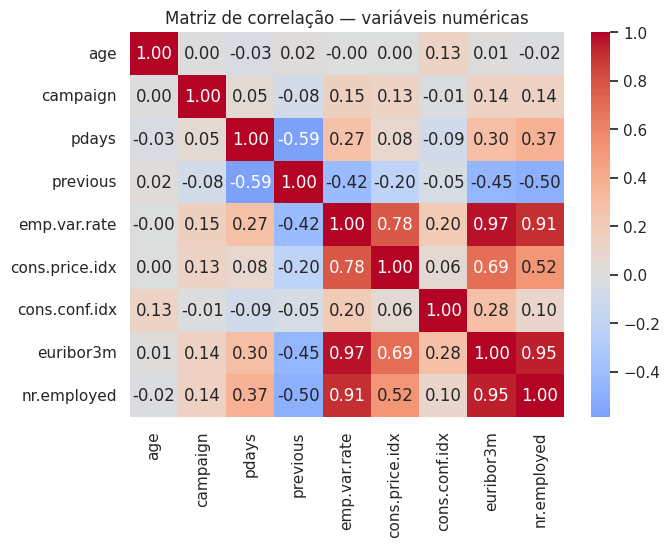

In [29]:
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Matriz de correlação — variáveis numéricas')
plt.show()


## 9. Idade x conversão (visão cruzada)


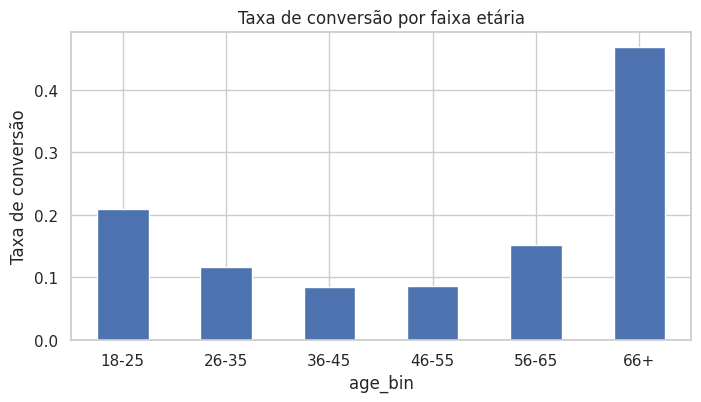

In [31]:
df['age_bin'] = pd.cut(df['age'], bins=[17, 25, 35, 45, 55, 65, 100],
                       labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66+'])

conv_by_age = df.groupby('age_bin', observed=True)['y'].apply(lambda s: (s == 'yes').mean())

fig, ax = plt.subplots()
conv_by_age.plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_title('Taxa de conversão por faixa etária')
ax.set_ylabel('Taxa de conversão')
plt.xticks(rotation=0)
plt.show()

df = df.drop(columns=['age_bin'])  # coluna auxiliar, não faz parte do dataset tratado


**Observação:** clientes mais jovens (18-25) e mais velhos (56+) convertem proporcionalmente mais — outro indício de que segmentar por contexto (idade, profissão, histórico) tem valor real para a política adaptativa.


## 10. Dataset tratado — resumo final

Ao final desta etapa, o dataframe `df`:
- Não possui duplicados
- Não possui a coluna `duration` (vazamento temporal)
- Mantém `unknown` como categoria válida (tratamento de encoding fica para a Etapa 2/3, junto da modelagem)
- Está pronto para virar `X` (features) e `y` (target) na Etapa 2 — Preparação da Base


In [32]:
print("Shape final:", df.shape)
print("\nColunas finais:", list(df.columns))
df.head()


Shape final: (41176, 20)

Colunas finais: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [33]:
# Salva o dataset tratado para ser consumido diretamente na Etapa 2/3
df.to_csv("bank_treated.csv", index=False)
print("Arquivo 'bank_treated.csv' salvo com sucesso.")


Arquivo 'bank_treated.csv' salvo com sucesso.
